# Agent Supervisor

![](https://d.pr/i/gKezSO+)

In [1]:
%pip install -Uqqq langchain-experimental langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

# 도구 생성

In [5]:
from langchain_tavily import TavilySearch # Tavily 웹 검색
from langchain_experimental.tools import PythonREPLTool # 파이썬 코드 실행 Tool

tavily_tool = TavilySearch(max_result =3)
python_repl_tool = PythonREPLTool() 

In [6]:
# 에이전트 노드 실행기 : 각 에이전트 답변을 사람메시지로 재가공하는 헬퍼 함수
from langchain_core.messages import HumanMessage

# 에이전트를 실행하고, 마지막 ai 응답을 HumanMessage 로 감싸 반환하는 함수
def agent_node(state, agent, name):
    response = agent.invoke(state)
    # 마지막 응답은 지정된 name의 HumanMessage 형태로 반환
    return {'messages' : [HumanMessage(content=response['messages'][-1].content, name=name)]}

## Supervisor Agent 구성
- 다음 작업자(Researcher / Coder / FINISH) 결정

In [15]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder # 중간 대화 삽입
from langchain.chat_models import init_chat_model
from pydantic import BaseModel  # 구조화 출력
from typing import Literal      # 값 제한

members = ['Researcher', 'Coder']   # 하위 에이전트
system_prompt = """  # Supervisor 역할/지침(system) 프롬프트
다음 작업자들 간의 대화를 관리하는 관리자로서 당신은 다음 작업을 수행해야 합니다: {members}.

아래의 사용자 요청을 참고하여, 다음 작업을 수행할 작업자를 지정하세요.
각 작업자는 작업을 수행하고 그 결과와 상태를 보고할 것입니다.
모든 작업이 완료되면 FINISH로 응답하세요."
"""

llm = init_chat_model('gpt-5.4-mini')

options = members + ['FINISH'] # Supervisor 의 선택지

# Supervisor 응답은 구조화된 형태
class RouteResponse(BaseModel):
    next: Literal["FINISH", "Researcher", "Coder"] # 다음 행동은 3개 중 하나로 제한

prompt = ChatPromptTemplate.from_messages([
    ('system', system_prompt),
    MessagesPlaceholder(variable_name= 'messages'), # 지금까지의 대화 내용 추가
    ('system', '''
위 대화를 참고하여, 누가 다음으로 행동해야 하나요? 아니면 작업을 FINISH 해야 하나요?
다음중 하나를 선택하세요: {options}

    ''')
]).partial(options=options, members=', '.join(members)) # partial : options/members 미리 고정

# 현재까지의 대화내용을 확인하여 다음 작업자를 라우팅해주는 Supervisor 함수
def supervisor_agent(state):
    # 프롬프트 + LLM 의 응답을 RouteResponse 파싱
    supervisor_chain = prompt | llm.with_structured_output(RouteResponse)
    return supervisor_chain.invoke(state) # next 값 반환


## Graph 조립

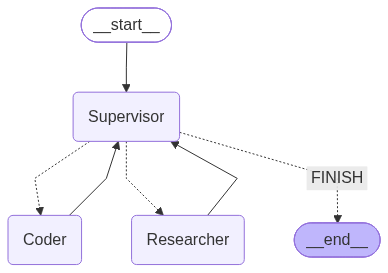

In [16]:
from typing import TypedDict, Annotated, List       # 상태 타입 정의
from langgraph.graph import StateGraph, START, END  # Langgraph 구성요소
from langgraph.graph.message import add_messages    # Messages 누적 처리 유틸
from langchain_core.messages import BaseMessage     # Messages 타입 힌트 정의
from langchain.agents import create_agent           # Tool 사용하는 에이전트
import functools # partial 사용 (값을 미리 고정)

# 그래프에서 사용할 상태 스키마 커스터마이징
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages] # messages는 add_messages의 규칙으로 누적
    next:str # Supervisor 가 결정한 다음 노드

research_agent = create_agent(llm, tools=[tavily_tool])
# functools.partial() : 기존 함수의 일부 인자를 미리 채운 함수를 반환
# agent_node에 agent/name을 미리 정해줌
research_node = functools.partial(agent_node, agent =research_agent, name= 'Researcher')

code_agent = create_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name='Coder')

workflow = StateGraph(AgentState)

# 노드
workflow.add_node('Supervisor', supervisor_agent)
workflow.add_node('Researcher', research_node)
workflow.add_node('Coder', code_node)

# 엣지
workflow.add_edge(START, 'Supervisor')
workflow.add_edge('Researcher', 'Supervisor')
workflow.add_edge('Coder', 'Supervisor')

conditional_map = {member : member for member in members} # {'Researcher': 'Researcher', ...}
conditional_map['FINISH'] = END

workflow.add_conditional_edges('Supervisor', lambda state: state['next'], conditional_map)
graph = workflow.compile()
graph


In [ ]:
# 노드별 출력
for chunk in graph.stream({
    'messages' : [
        ('human', '파이썬 HelloWorld 출력하는 코드를 작성하고, 콘솔에 출력해줘!')
    ]
}):
    print(chunk) # 노드 메시지 출력


{'Supervisor': {'next': 'Coder'}}
{'Coder': {'messages': [HumanMessage(content='```python\nprint("Hello, World!")\n```\n\n콘솔 출력 결과:\n```text\nHello, World!\n```', additional_kwargs={}, response_metadata={}, name='Coder', id='dd56dc7b-7a87-4afa-a142-30c80c9f1d74')]}}
{'Supervisor': {'next': 'FINISH'}}


{'Supervisor': {'next': 'Coder'}}


Python REPL can execute arbitrary code. Use with caution.


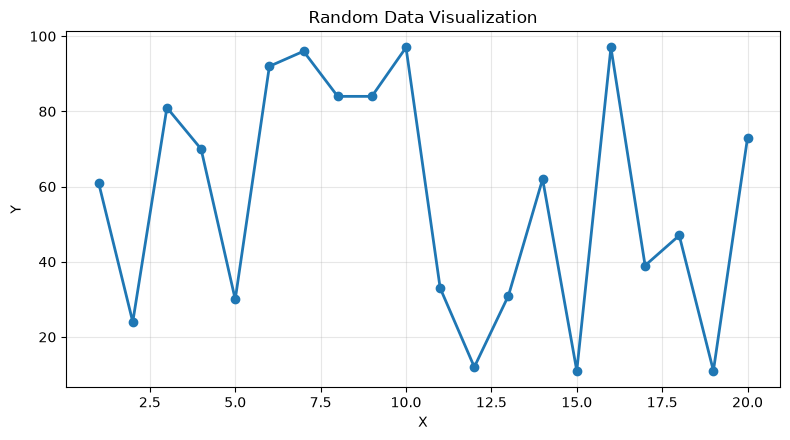

{'Coder': {'messages': [HumanMessage(content='임의의 데이터를 `matplotlib`로 선 그래프로 시각화했습니다.  \n원하시면 제가 바로 다음 중 하나로도 바꿔드릴 수 있어요:\n\n- 막대그래프\n- 산점도\n- 히스토그램\n- 여러 개의 임의 데이터 비교 그래프\n- 한글 제목/축 라벨 적용\n\n원하시면 바로 코드도 같이 드릴게요.', additional_kwargs={}, response_metadata={}, name='Coder', id='00ee9134-1bc0-49e0-9f30-76b8e5d5f2b2')]}}
{'Supervisor': {'next': 'FINISH'}}


In [21]:
for chunk in graph.stream({
    'messages' : [
        ('human', '임의의 데이터를 matplotlib로 시각화 해줘')
    ]
}):
    print(chunk) # 노드 메시지 출력


In [33]:
for chunk in graph.stream({
    'messages' : [
        ('human', '연도별 산불 현황 자료를 검색해서 파이썬 matplotlib로 선 그래프 시각화 반드시 해야해')
    ]
}):
    print(chunk) # 노드 메시지 출력

{'Supervisor': {'next': 'Researcher'}}
{'Researcher': {'messages': [HumanMessage(content="아래 자료를 기준으로 **연도별 산불 발생 건수**를 정리하고, **Python matplotlib 선 그래프**로 시각화할 수 있습니다.\n\n## 1) 검색한 공식 자료\n산림청 공식 페이지의 **산불발생현황**에서 연도별 산불 발생 건수를 확인했습니다.\n\n출처:\n- 산림청 산불발생현황: https://www.forest.go.kr/kfsweb/kfi/kfs/frfr/selectFrfrStats.do?mn=AR04_01_03\n\n검색 결과에 나온 연도별 산불 발생 건수는 다음과 같습니다.\n\n| 연도 | 발생 건수 |\n|---|---:|\n| 2016 | 391 |\n| 2017 | 692 |\n| 2018 | 496 |\n| 2019 | 653 |\n| 2020 | 620 |\n| 2021 | 349 |\n| 2022 | 756 |\n| 2023 | 596 |\n| 2024 | 279 |\n| 2025 | 459 |\n\n---\n\n## 2) matplotlib 선 그래프 코드\n\n```python\nimport matplotlib.pyplot as plt\n\n# 한글 폰트 설정(환경에 따라 다를 수 있음)\nplt.rcParams['font.family'] = 'Malgun Gothic'   # Windows\nplt.rcParams['axes.unicode_minus'] = False\n\nyears = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]\nfires = [391, 692, 496, 653, 620, 349, 756, 596, 279, 459]\n\nplt.figure(figsize=(10, 6))\nplt.plot(years, fires, marker='o', linestyle='-', color='re